# ДЗ 3 Разметка данных

Смоделируем ситуацию.

Мы уже спарсили датасет, обогатили и очистили данные, готовы предсказывать цены на квартиры. И тут приходит менеджер и говорит:

"Вся эта ваша статистика - фигня полная, квартиры хайпуют на крутых описаниях. Придумайте как отранжировать описания квартир, например, от одного до пяти".

И вот, сели мы всей командой (из одного человека) думать.

In [14]:
import dill
from navec import Navec
from slovnet import NER

from natasha import (
    Segmenter,
    MorphVocab,

    NewsEmbedding,
    NewsMorphTagger,
    
    Doc
)

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

import math

from sklearn.metrics import cohen_kappa_score, classification_report

In [15]:
OUTPUT_PATH = "../artifacts/cian_dataset_enriched.dill"

In [16]:
with open(OUTPUT_PATH, "rb") as f:
    try:
        df = dill.load(f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

df.desc.head()

0    Продаются апартаменты общей площадью 173,3 кв....
1    Старт продаж нового корпуса \n  \nЖилой компле...
2    Уютная квартира с двумя спальными комнатами, п...
3    Выдача ключей! Квартира с отделкой White Box M...
4    Продаются апартаменты с сервисом 5* отеля на 5...
Name: desc, dtype: object

In [17]:
# С первого взгляда вообще не понятно что там в описаниях и что с ними можно делать. Давайте рассмотрим какой-нибудь объектик.
df.desc.iloc[0]

'Продаются апартаменты общей площадью 173,3 кв. м. с 2-мя спальнями и кухней-гостиной.Компания Vesper представляет проект "Левенсон" в исключительной локации — на Патриарших прудах. Проект собирает комбинацию из легендарных исторических зданий типографии поставщика императорского двора Александра Левенсона и объектов современной архитектуры. Новый проект Vesper создан для ценителей подлинных исторических особняков, наполненных совершенными технологиями, для создания абсолютного уровня комфорта и эстетики жизни. Клубный дом "Левенсон" объединяет сразу несколько форматов жилой недвижимости, отвечающих самым высоким запросам: современный дом, два исторических здания, частная резиденция. В проекте представлены квартиры и апартаменты с патио, таунхаусы, пентхаусы с террасами. Площадь лотов варьируется от 132 кв.м до 620 кв.м. Архитектурная концепция от бюро "Цимайло, Ляшенко и партнеры" гармонично дополняет шедевры модерна новыми формами и материалами. Все квартиры предлагаются с высококаче

#### Уф, сочное описание

Были бы деньги, точно бы купил. Но что тут цепляет? 

В первую очередь, конечно же топонимы - любой коренной житель своего города хотя бы приблизительно по топонимам понимает, крутое место или нет. А соответственно, крутая ли квартира. 

Во вторую очередь - семантика, т.е. подача. Конечно же, почти у всех объявлений будет комплиментарная семантика, поэтому с т.з. разметки нет смысла оценивать какую-то семантику. И так понятно, что в деле недвижимости даже самое барахло будут пытаться продать как роскошество.

Если мы говорим о топонимах, то это задача NER. Однако, что нам даст такая разметка, ведь менеджер просил придумать ранжирование? В таком случае, проведём TF_IDF взвешивание топонимов, чтобы вычленить некоторую географическую уникальность каждого объекта, и в конце разделим на ранги по распределению.

Итого задача:
1. NER (упрощённая) - выделить все спаны.
2. Перевзвешивание - использовать TF-IDF для выставления веса каждому спану.
3. Ранжирование - по итоговой сумме оценок спанов выставить объявлению ранг.

Не забываем, что своими безумными идеями придётся мучать коллег с курса, потому:
1. Разметим датасет эталонно целиком, чтобы было удобно считать метрики.
2. Придумаем метрику качества разметки рангов, по которой будем оценивать итоговую разметку (например, classification_report).
3. Рассчитаем метрику согласованности аннотаторов, например Cohen’s kappa.

In [18]:
dsc_list = df.desc.tolist()

In [19]:

text = dsc_list[0]

navec = Navec.load('../artifacts/navec_news_v1_1B_250K_300d_100q.tar')
ner = NER.load('../artifacts/slovnet_ner_news_v1.tar')
ner.navec(navec)
ner(text)

SpanMarkup(
    text='Продаются апартаменты общей площадью 173,3 кв. м. с 2-мя спальнями и кухней-гостиной.Компания Vesper представляет проект "Левенсон" в исключительной локации — на Патриарших прудах. Проект собирает комбинацию из легендарных исторических зданий типографии поставщика императорского двора Александра Левенсона и объектов современной архитектуры. Новый проект Vesper создан для ценителей подлинных исторических особняков, наполненных совершенными технологиями, для создания абсолютного уровня комфорта и эстетики жизни. Клубный дом "Левенсон" объединяет сразу несколько форматов жилой недвижимости, отвечающих самым высоким запросам: современный дом, два исторических здания, частная резиденция. В проекте представлены квартиры и апартаменты с патио, таунхаусы, пентхаусы с террасами. Площадь лотов варьируется от 132 кв.м до 620 кв.м. Архитектурная концепция от бюро "Цимайло, Ляшенко и партнеры" гармонично дополняет шедевры модерна новыми формами и материалами. Все квартиры пред

In [20]:
# мы видим что natasha определяет не только LOC теги, но и тег ORG. Давайте ради разнообразия в ДЗ оставим только LOC, вдруг это породит ошибки разметки.
dsc_ner = []

for elem in dsc_list:
    dsc_ner.append(ner(elem))

dsc_ner[0]

SpanMarkup(
    text='Продаются апартаменты общей площадью 173,3 кв. м. с 2-мя спальнями и кухней-гостиной.Компания Vesper представляет проект "Левенсон" в исключительной локации — на Патриарших прудах. Проект собирает комбинацию из легендарных исторических зданий типографии поставщика императорского двора Александра Левенсона и объектов современной архитектуры. Новый проект Vesper создан для ценителей подлинных исторических особняков, наполненных совершенными технологиями, для создания абсолютного уровня комфорта и эстетики жизни. Клубный дом "Левенсон" объединяет сразу несколько форматов жилой недвижимости, отвечающих самым высоким запросам: современный дом, два исторических здания, частная резиденция. В проекте представлены квартиры и апартаменты с патио, таунхаусы, пентхаусы с террасами. Площадь лотов варьируется от 132 кв.м до 620 кв.м. Архитектурная концепция от бюро "Цимайло, Ляшенко и партнеры" гармонично дополняет шедевры модерна новыми формами и материалами. Все квартиры пред

In [21]:
unique_types = set()
for rec in dsc_ner:
    for span in rec.spans:
        unique_types.add(span.type)

ner_types = ["O"] + sorted(unique_types)
spanToIdx = {ner: i for i, ner in enumerate(ner_types)}
idxToSpan = {i: ner for i, ner in enumerate(ner_types)}

print("idxToSpan:", idxToSpan)
print("spanToIdx:", spanToIdx)

idxToSpan: {0: 'O', 1: 'LOC', 2: 'ORG', 3: 'PER'}
spanToIdx: {'O': 0, 'LOC': 1, 'ORG': 2, 'PER': 3}


In [22]:
# ещё раз убеждаемся, что в нашем корпусе есть вся триада. Оставим только LOC

segmenter = Segmenter()
morph_vocab = MorphVocab()

emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

def extract_loc_tags(span_markup):
    loc_tags = []
    for span in span_markup.spans:
        if span.type == "LOC":
            loc_word = span_markup.text[span.start:span.stop]
            
            doc = Doc(loc_word)
        
            doc.segment(segmenter)
            
            doc.tag_morph(morph_tagger)
    
            for token in doc.tokens:
                token.lemmatize(morph_vocab)
            loc_tags.append(" ".join(token.lemma for token in doc.tokens))
    return {"text": span_markup.text, "tags": loc_tags}


dsc_tags = [extract_loc_tags(item) for item in dsc_ner]
dsc_tags[0]

{'text': 'Продаются апартаменты общей площадью 173,3 кв. м. с 2-мя спальнями и кухней-гостиной.Компания Vesper представляет проект "Левенсон" в исключительной локации — на Патриарших прудах. Проект собирает комбинацию из легендарных исторических зданий типографии поставщика императорского двора Александра Левенсона и объектов современной архитектуры. Новый проект Vesper создан для ценителей подлинных исторических особняков, наполненных совершенными технологиями, для создания абсолютного уровня комфорта и эстетики жизни. Клубный дом "Левенсон" объединяет сразу несколько форматов жилой недвижимости, отвечающих самым высоким запросам: современный дом, два исторических здания, частная резиденция. В проекте представлены квартиры и апартаменты с патио, таунхаусы, пентхаусы с террасами. Площадь лотов варьируется от 132 кв.м до 620 кв.м. Архитектурная концепция от бюро "Цимайло, Ляшенко и партнеры" гармонично дополняет шедевры модерна новыми формами и материалами. Все квартиры предлагаются с в

In [23]:
# Мы видим повторения топонимов и это как раз то, что нам нужно, чтобы посчитать tf-idf для каждого из них. А потом просто суммируем

docs_str = [' '.join(tags['tags']) for tags in dsc_tags]

vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), preprocessor=lambda x: x)
tfidf_matrix = vectorizer.fit_transform(docs_str)

feature_names = vectorizer.get_feature_names_out()
sum_tfidf = tfidf_matrix.sum(axis=1).A1



result_df = pd.DataFrame({'desc': [tags["text"] for tags in dsc_tags], 'tag': [tags["tags"] for tags in dsc_tags], 'sum_tfidf': sum_tfidf})
result_df.head()

D:\projects\data_for_ML\venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,desc,tag,sum_tfidf
0,"Продаются апартаменты общей площадью 173,3 кв....","[патриарший пруд, патриарший пруд]",1.371213
1,Старт продаж нового корпуса \n \nЖилой компле...,"[москва, кутузовский проспект, москва, москва,...",2.929396
2,"Уютная квартира с двумя спальными комнатами, п...","[фрунзенский набережная, кремль, москва-река, ...",2.814539
3,Выдача ключей! Квартира с отделкой White Box M...,"[нептун, москва-река, даниловский рынок, тюфел...",2.398998
4,Продаются апартаменты с сервисом 5* отеля на 5...,"[триумфальный площадь, тверской улица, патриар...",2.709993


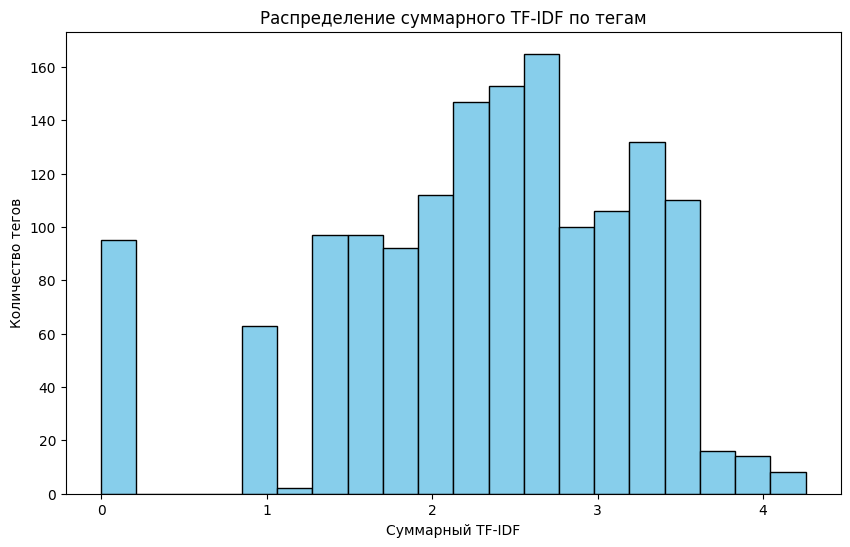

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(result_df['sum_tfidf'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Суммарный TF-IDF')
plt.ylabel('Количество тегов')
plt.title('Распределение суммарного TF-IDF по тегам')
plt.show()

In [25]:
# Класс, мы не подгадывали, а вышло ровно 5 категорий. Давайте их проставим

result_df['rank'] = result_df['sum_tfidf'].apply(math.ceil)
result_df.head()

,desc,tag,sum_tfidf,rank
0,"Продаются апартаменты общей площадью 173,3 кв....","[патриарший пруд, патриарший пруд]",1.371213,2
1,Старт продаж нового корпуса \n \nЖилой компле...,"[москва, кутузовский проспект, москва, москва,...",2.929396,3
2,"Уютная квартира с двумя спальными комнатами, п...","[фрунзенский набережная, кремль, москва-река, ...",2.814539,3
3,Выдача ключей! Квартира с отделкой White Box M...,"[нептун, москва-река, даниловский рынок, тюфел...",2.398998,3
4,Продаются апартаменты с сервисом 5* отеля на 5...,"[триумфальный площадь, тверской улица, патриар...",2.709993,3


In [26]:
# класс, разметка окончена, сохраним датасет
DATASET_PATH = "../artifacts/marked_texts.dill"

with open(DATASET_PATH, "wb") as f:
    try:
        dill.dump(result_df, f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

### Метрики

Давайте сымитируем ситуацию, когда наш датасет разметили два разных разметчика.

Для каждого из них посчитаем качество разметки, а между ними - метрику согласованности

In [27]:
test_df = result_df.drop(columns=['tag', 'sum_tfidf'])

# внесём ошибок в разметку. Заменим случайные 50 рангов нулями

marked1 = test_df.copy()
random_indices1 = marked1['rank'].sample(n=150, random_state=42).index
marked1.loc[random_indices1, 'rank'] = 0

marked2 = test_df.copy()
random_indices2 = marked2['rank'].sample(n=250, random_state=0).index
marked2.loc[random_indices2, 'rank'] = 0

In [28]:
# Отлично, есть какая-то ошибка. Погнали считать метрики

report = classification_report(test_df['rank'], marked1['rank'], zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.40      1.00      0.57        95
           1       1.00      0.92      0.96        63
           2       1.00      0.89      0.94       332
           3       1.00      0.90      0.94       649
           4       1.00      0.92      0.96       362
           5       1.00      0.75      0.86         8

    accuracy                           0.91      1509
   macro avg       0.90      0.90      0.87      1509
weighted avg       0.96      0.91      0.92      1509



In [29]:
report = classification_report(test_df['rank'], marked2['rank'], zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.29      1.00      0.44        95
           1       1.00      0.84      0.91        63
           2       1.00      0.81      0.90       332
           3       1.00      0.80      0.89       649
           4       1.00      0.90      0.95       362
           5       1.00      0.75      0.86         8

    accuracy                           0.84      1509
   macro avg       0.88      0.85      0.82      1509
weighted avg       0.96      0.84      0.88      1509



In [30]:
# эти отчёты можно сохранить как артефакты

report_dict_1 = classification_report(test_df['rank'], marked1['rank'], output_dict=True, zero_division=0)
report_dict_2 = classification_report(test_df['rank'], marked2['rank'], output_dict=True, zero_division=0)

student_1_path = "../artifacts/report1.dill"
student_2_path = "../artifacts/report2.dill"

with open(student_1_path, "wb") as f:
    try:
        dill.dump(report_dict_1, f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

with open(student_2_path, "wb") as f:
    try:
        dill.dump(student_2_path, f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

In [31]:
# Ну и, наконец, метрика согласованности

kappa = cohen_kappa_score(marked1['rank'], marked2['rank'])
print(kappa)

0.7060671309470029


In [32]:
kappa_path = "../artifacts/kappa.dill"

with open(kappa_path, "wb") as f:
    try:
        dill.dump(kappa, f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

In [33]:
TASK_PATH = "../artifacts/IM_task.dill"

with open(TASK_PATH, "wb") as f:
    try:
        dill.dump(test_df['desc'], f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

with open(TASK_PATH, "rb") as f:
    try:
        df_readed = dill.load(f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

df_readed.head()

0    Продаются апартаменты общей площадью 173,3 кв....
1    Старт продаж нового корпуса \n  \nЖилой компле...
2    Уютная квартира с двумя спальными комнатами, п...
3    Выдача ключей! Квартира с отделкой White Box M...
4    Продаются апартаменты с сервисом 5* отеля на 5...
Name: desc, dtype: object